In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
forecast_df = pd.read_csv(
    "../data/forecast_predictions.csv"
)

forecast_df["Date"] = pd.to_datetime(
    forecast_df["Date"]
)

forecast_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Quarter,Week,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_std_4,rolling_mean_8,Predicted_Sales
0,1,1,2012-02-03,23510.49,False,56.55,3.360,34577.06,3579.21,160.53,...,1,5,18378.16,18365.10,16567.69,33305.92,17551.3375,956.551817,27427.99125,22266.592
1,1,1,2012-02-10,36988.49,True,48.02,3.409,13925.06,6927.23,101.64,...,1,6,23510.49,18378.16,16894.40,45773.03,19287.0375,2900.476529,26203.56250,33854.535
2,1,1,2012-02-17,54060.10,False,45.32,3.510,9873.33,11062.27,9.80,...,1,7,36988.49,23510.49,18365.10,46788.75,24310.5600,8792.267160,25105.49500,35436.535
3,1,1,2012-02-24,20124.22,False,57.25,3.555,9349.61,7556.01,3.20,...,1,8,54060.10,36988.49,18378.16,23350.88,33234.3100,15948.513670,26014.41375,31604.060
4,1,1,2012-03-02,20113.03,False,60.96,3.630,15441.40,1569.00,10.80,...,1,9,20124.22,54060.10,23510.49,16567.69,33670.8250,15421.547160,25611.08125,10765.133


In [3]:
forecast_df["Demand_STD"] = (
    forecast_df
    .groupby(
        ["Store","Dept"]
    )["Weekly_Sales"]
    .transform("std")
)

In [4]:
forecast_df[
[
"Store",
"Dept",
"Weekly_Sales",
"Demand_STD"
]
].head()

,Store,Dept,Weekly_Sales,Demand_STD
0,1,1,23510.49,9385.596924
1,1,1,36988.49,9385.596924
2,1,1,54060.10,9385.596924
3,1,1,20124.22,9385.596924
4,1,1,20113.03,9385.596924


In [5]:
z_score = 1.65
lead_time = 2

forecast_df["Safety_Stock"] = (

    z_score

    *

    forecast_df["Demand_STD"]

    *

    np.sqrt(lead_time)

)

In [6]:
forecast_df["Average_Demand"] = (

    forecast_df

    .groupby(
        ["Store","Dept"]
    )["Predicted_Sales"]

    .transform("mean")

)

In [7]:
forecast_df["Reorder_Point"] = (

    forecast_df["Average_Demand"]

    *

    lead_time

    +

    forecast_df["Safety_Stock"]

)

In [8]:
ordering_cost = 100
holding_cost = 5

forecast_df["Annual_Demand"] = (

    forecast_df["Average_Demand"]

    *

    52

)

In [9]:
forecast_df["EOQ"] = np.sqrt(

    (

        2

        *

        forecast_df["Annual_Demand"]

        *

        ordering_cost

    )

    /

    holding_cost

)

d:\forecasting\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
forecast_df["Recommended_Order_Qty"] = (

    forecast_df["Predicted_Sales"]

    +

    forecast_df["Safety_Stock"]

)

In [11]:
inventory_results = forecast_df[
[
"Store",
"Dept",
"Date",

"Predicted_Sales",

"Safety_Stock",

"Reorder_Point",

"EOQ",

"Recommended_Order_Qty"
]
]

inventory_results.head(20)

,Store,Dept,Date,Predicted_Sales,Safety_Stock,Reorder_Point,EOQ,Recommended_Order_Qty
0,1,1,2012-02-03,22266.592,21900.843461,63747.510538,6597.009456,44167.435461
1,1,1,2012-02-10,33854.535,21900.843461,63747.510538,6597.009456,55755.378461
2,1,1,2012-02-17,35436.535,21900.843461,63747.510538,6597.009456,57337.378461
3,1,1,2012-02-24,31604.060,21900.843461,63747.510538,6597.009456,53504.903461
4,1,1,2012-03-02,10765.133,21900.843461,63747.510538,6597.009456,32665.976461
5,1,1,2012-03-09,20367.303,21900.843461,63747.510538,6597.009456,42268.146461
6,1,1,2012-03-16,21175.482,21900.843461,63747.510538,6597.009456,43076.325461
7,1,1,2012-03-23,25471.854,21900.843461,63747.510538,6597.009456,47372.697461
8,1,1,2012-03-30,25842.863,21900.843461,63747.510538,6597.009456,47743.706461
9,1,1,2012-04-06,35845.742,21900.843461,63747.510538,6597.009456,57746.585461


In [12]:
inventory_results.to_csv(

    "../data/inventory_optimization_results.csv",

    index=False

)

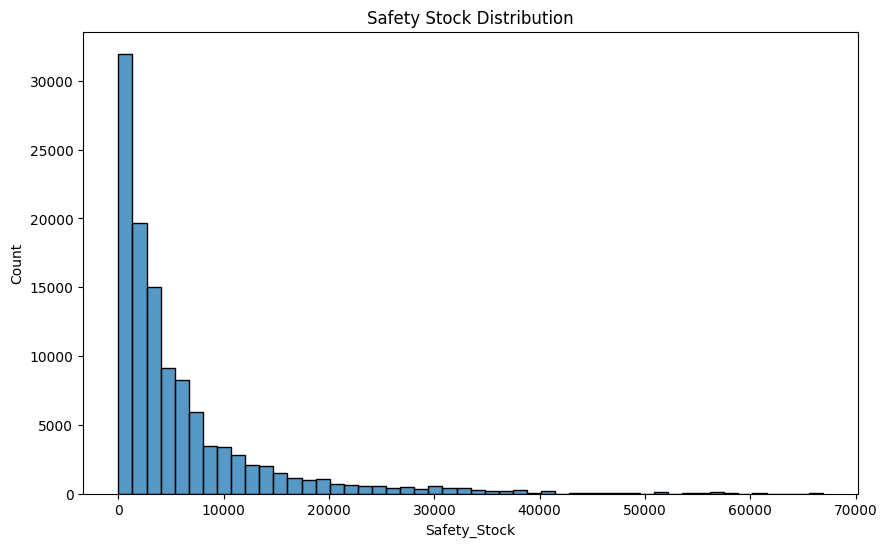

In [13]:
plt.figure(
    figsize=(10,6)
)

sns.histplot(

    inventory_results["Safety_Stock"],

    bins=50

)

plt.title(
    "Safety Stock Distribution"
)

plt.show()

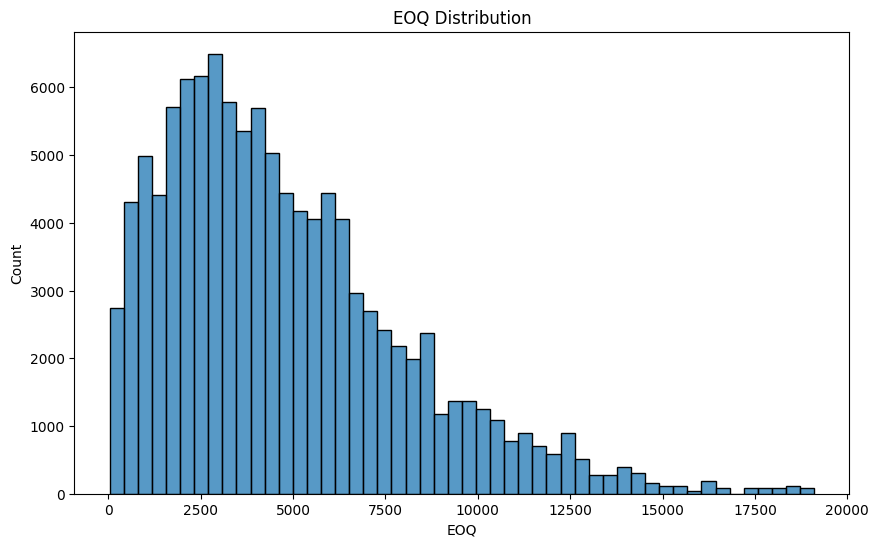

In [14]:
plt.figure(
    figsize=(10,6)
)

sns.histplot(

    inventory_results["EOQ"],

    bins=50

)

plt.title(
    "EOQ Distribution"
)

plt.show()

In [15]:
inventory_results.sort_values(

    by="Safety_Stock",

    ascending=False

).head(10)

,Store,Dept,Date,Predicted_Sales,Safety_Stock,Reorder_Point,EOQ,Recommended_Order_Qty
26016,10,72,2012-08-03,107076.875,66900.658051,296806.776,15462.935125,173977.533051
26013,10,72,2012-07-13,105307.510,66900.658051,296806.776,15462.935125,172208.168051
26018,10,72,2012-08-17,113718.950,66900.658051,296806.776,15462.935125,180619.608051
26019,10,72,2012-08-24,112570.630,66900.658051,296806.776,15462.935125,179471.288051
26020,10,72,2012-08-31,117475.000,66900.658051,296806.776,15462.935125,184375.658051
26009,10,72,2012-06-15,109582.600,66900.658051,296806.776,15462.935125,176483.258051
26011,10,72,2012-06-29,109365.836,66900.658051,296806.776,15462.935125,176266.494051
26012,10,72,2012-07-06,110225.695,66900.658051,296806.776,15462.935125,177126.353051
26015,10,72,2012-07-27,100186.875,66900.658051,296806.776,15462.935125,167087.533051
25991,10,72,2012-02-10,153757.060,66900.658051,296806.776,15462.935125,220657.718051


In [16]:
inventory_results.sort_values(

    by="Recommended_Order_Qty",

    ascending=False

).head(10)

,Store,Dept,Date,Predicted_Sales,Safety_Stock,Reorder_Point,EOQ,Recommended_Order_Qty
37397,14,92,2012-02-10,198289.70,57169.534025,408096.711461,19104.037912,255459.234025
37409,14,92,2012-05-04,195365.73,57169.534025,408096.711461,19104.037912,252535.264025
37396,14,92,2012-02-03,195116.16,57169.534025,408096.711461,19104.037912,252285.694025
37405,14,92,2012-04-06,189875.02,57169.534025,408096.711461,19104.037912,247044.554025
37426,14,92,2012-08-31,187822.94,57169.534025,408096.711461,19104.037912,244992.474025
37398,14,92,2012-02-17,187822.02,57169.534025,408096.711461,19104.037912,244991.554025
37415,14,92,2012-06-15,187421.39,57169.534025,408096.711461,19104.037912,244590.924025
37416,14,92,2012-06-22,187308.70,57169.534025,408096.711461,19104.037912,244478.234025
37399,14,92,2012-02-24,186843.11,57169.534025,408096.711461,19104.037912,244012.644025
37406,14,92,2012-04-13,186441.98,57169.534025,408096.711461,19104.037912,243611.514025
